In [5]:
# ============================================
# DRUG REPURPOSING ASSIGNMENT - COMPLETE CODE
# Asthma ICD-10 J45 Classification
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Sampling
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# RDKit
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit.Chem import AllChem
from rdkit import DataStructs





In [11]:
# ============================================
# TASK 1: LOAD DATA AND CREATE X, Y
# ============================================

import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

file_path = "icd (2).csv"

# Read file WITHOUT headers
df = pd.read_csv(file_path, header=None)

print("Dataset preview:")
print(df.head())

# Rename single column
df.columns = ["raw_data"]

# Split SMILES and ICD codes
df[["SMILES", "ICD"]] = df["raw_data"].str.split(";", expand=True)

print("\nProcessed preview:")
print(df.head())

# ============================================
# Convert SMILES to fingerprints
# ============================================

def smiles_to_fingerprint(smiles, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )

    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)

    return arr

fingerprints = []
labels = []

for _, row in df.iterrows():
    smiles = row["SMILES"]
    icd_code = str(row["ICD"])

    fp = smiles_to_fingerprint(smiles)

    if fp is None:
        continue

    # Asthma parent ICD-10 category
    label = 1 if "J40-J47" in icd_code else 0

    fingerprints.append(fp)
    labels.append(label)

X = np.array(fingerprints)
y = np.array(labels)

print("Class distribution:", np.bincount(y))
print("\nTASK 1 COMPLETE")
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Class distribution:", np.bincount(y))

Dataset preview:
                                                   0
0  NC(=O)C([C@@H]1CCN(CCC2=CC3=C(OCC3)C=C2)C1)(C1...
1                            NC(CCC(O)=O)C=C;R25-R29
2  CC(C)(C#N)C1=CC(=CC(CN2C=NC=N2)=C1)C(C)(C)C#N;...
3  O.O.O.O.O.O.O.O.O.[Na+].[Na+].[Na+].[H][C@@]1(...
4  [H][C@@]12CCC[C@]1([H])N([C@@H](C2)C(O)=O)C(=O...

Processed preview:
                                            raw_data  \
0  NC(=O)C([C@@H]1CCN(CCC2=CC3=C(OCC3)C=C2)C1)(C1...   
1                            NC(CCC(O)=O)C=C;R25-R29   
2  CC(C)(C#N)C1=CC(=CC(CN2C=NC=N2)=C1)C(C)(C)C#N;...   
3  O.O.O.O.O.O.O.O.O.[Na+].[Na+].[Na+].[H][C@@]1(...   
4  [H][C@@]12CCC[C@]1([H])N([C@@H](C2)C(O)=O)C(=O...   

                                              SMILES      ICD  
0  NC(=O)C([C@@H]1CCN(CCC2=CC3=C(OCC3)C=C2)C1)(C1...  N30-N39  
1                                    NC(CCC(O)=O)C=C  R25-R29  
2      CC(C)(C#N)C1=CC(=CC(CN2C=NC=N2)=C1)C(C)(C)C#N  N80-N98  
3  O.O.O.O.O.O.O.O.O.[Na+].[Na+].[Na+].[H][C@@]1(...

[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerator
[23:16:26] DEPRECATION WARNING: please use MorganGenerat

Class distribution: [998 107]

TASK 1 COMPLETE
Feature matrix shape: (1105, 1024)
Label vector shape: (1105,)
Class distribution: [998 107]


[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerator
[23:16:27] DEPRECATION WARNING: please use MorganGenerat


TASK 2: CLASS DISTRIBUTION
{np.int64(0): np.int64(998), np.int64(1): np.int64(107)}
Inactive compounds: 998
Active compounds: 107
Imbalance ratio: 9.33


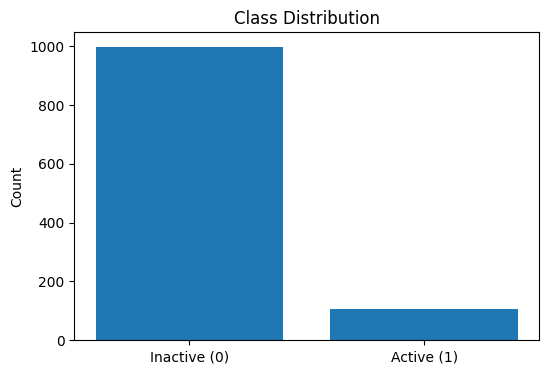

In [12]:
# ============================================
# TASK 2: CLASS DISTRIBUTION
# ============================================

unique, counts = np.unique(y, return_counts=True)

class_distribution = dict(zip(unique, counts))

print("\nTASK 2: CLASS DISTRIBUTION")
print(class_distribution)

inactive = class_distribution.get(0, 0)
active = class_distribution.get(1, 0)

print(f"Inactive compounds: {inactive}")
print(f"Active compounds: {active}")

imbalance_ratio = inactive / active if active > 0 else 0
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

plt.figure(figsize=(6,4))
plt.bar(["Inactive (0)", "Active (1)"], [inactive, active])
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


TASK 3: BASELINE MODEL PERFORMANCE
Logistic Regression: 0.9174 (+/- 0.0182)
LDA: 0.9107 (+/- 0.0177)
KNN: 0.9084 (+/- 0.0104)
Decision Tree: 0.8949 (+/- 0.0235)
Naive Bayes: 0.8190 (+/- 0.0293)
SVM: 0.9118 (+/- 0.0098)
Random Forest: 0.9174 (+/- 0.0152)


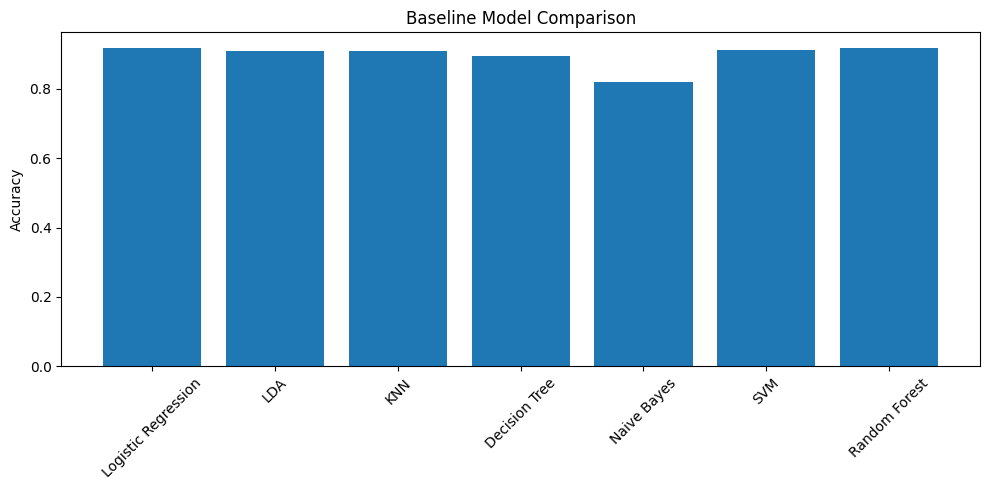

In [13]:
# ============================================
# TASK 3: BASELINE MODELS
# ============================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "LDA": LinearDiscriminantAnalysis(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

baseline_results = {}

print("\nTASK 3: BASELINE MODEL PERFORMANCE")

for name, model in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    baseline_results[name] = scores.mean()

    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Plot
plt.figure(figsize=(10,5))
plt.bar(baseline_results.keys(), baseline_results.values())
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Baseline Model Comparison")
plt.tight_layout()
plt.show()



In [14]:
# ============================================
# TASK 4: APPLY BALANCING
# ============================================

print("\nTASK 4: BALANCED DATASETS")

# Oversampling
ros = RandomOverSampler(random_state=42)
X_over, y_over = ros.fit_resample(X_train, y_train)

# Undersampling
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)

print("Original:", np.bincount(y_train))
print("Oversampled:", np.bincount(y_over))
print("Undersampled:", np.bincount(y_under))

balanced_results = {}

for dataset_name, X_bal, y_bal in [
    ("Oversampled", X_over, y_over),
    ("Undersampled", X_under, y_under)
]:
    print(f"\n{dataset_name} Results:")

    for name, model in models.items():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        scores = cross_val_score(
            pipeline,
            X_bal,
            y_bal,
            cv=cv,
            scoring="accuracy"
        )

        balanced_results[f"{dataset_name}-{name}"] = scores.mean()

        print(f"{name}: {scores.mean():.4f}")




TASK 4: BALANCED DATASETS
Original: [798  86]
Oversampled: [798 798]
Undersampled: [86 86]

Oversampled Results:
Logistic Regression: 0.9530
LDA: 0.9449
KNN: 0.9455
Decision Tree: 0.9392
Naive Bayes: 0.9367
SVM: 0.9599
Random Forest: 0.9593

Undersampled Results:
Logistic Regression: 0.7092
LDA: 0.7095
KNN: 0.5637
Decision Tree: 0.6631
Naive Bayes: 0.6399
SVM: 0.6745
Random Forest: 0.6863


In [15]:
# ============================================
# TASK 5: PARAMETER TUNING
# ============================================

print("\nTASK 5: PARAMETER CHANGES")

tuned_models = {
    "Random Forest depth=10":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            random_state=42
        ),

    "SVM RBF":
        SVC(kernel='rbf', C=2),

    "KNN k=7":
        KNeighborsClassifier(n_neighbors=7),

    "Morgan 2048 bits":
        None
}

for name, model in tuned_models.items():
    if model is None:
        continue

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    print(f"{name}: {scores.mean():.4f}")

# ============================================
# FINAL TEST EVALUATION
# ============================================

print("\nFINAL TEST SET EVALUATION")

best_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

best_model.fit(X_over, y_over)

predictions = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))




TASK 5: PARAMETER CHANGES
Random Forest depth=10: 0.9152
SVM RBF: 0.9163
KNN k=7: 0.9073

FINAL TEST SET EVALUATION
Accuracy: 0.8868778280542986

Confusion Matrix:
[[189  11]
 [ 14   7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       200
           1       0.39      0.33      0.36        21

    accuracy                           0.89       221
   macro avg       0.66      0.64      0.65       221
weighted avg       0.88      0.89      0.88       221



In [16]:
# ============================================
# TASK 6 DISCUSSION OUTPUT
# ============================================

print("\nTASK 6 DISCUSSION POINTS")
print("""
1. External validation on independent datasets is required.
2. Biological activity validation in wet lab experiments is necessary.
3. Clinical safety assessment must be performed.
4. More advanced descriptors could improve performance.
5. Hyperparameter optimization should be expanded.
6. Dataset quality and ICD label ambiguity may limit accuracy.
7. Class imbalance can distort model performance.
8. Accuracy alone may be insufficient—ROC-AUC, F1, recall should also be assessed.
""")


TASK 6 DISCUSSION POINTS

1. External validation on independent datasets is required.
2. Biological activity validation in wet lab experiments is necessary.
3. Clinical safety assessment must be performed.
4. More advanced descriptors could improve performance.
5. Hyperparameter optimization should be expanded.
6. Dataset quality and ICD label ambiguity may limit accuracy.
7. Class imbalance can distort model performance.
8. Accuracy alone may be insufficient—ROC-AUC, F1, recall should also be assessed.

